# **Nama Proyek**    - Analisis Penjualan Regional Amerika Serikat

## 🗂️ **Ringkasan Proyek**  


Notebook EDA ini membahas dataset penjualan Acme Co. di Amerika Serikat (USA) periode 2014–2018 melalui:

**Profiling & Pembersihan Data:** Memverifikasi struktur data, menangani data budget yang hilang, dan memperbaiki tipe data.

**Analisis Univariat & Bivariat:** Mengeksplorasi distribusi data (pendapatan, margin, harga per unit), serta menganalisis penjualan berdasarkan produk, kanal, wilayah, dan segmen pelanggan.

**Tren & Musiman:** Membuat visualisasi pola penjualan bulanan dan tahunan untuk mengidentifikasi lonjakan dan penurunan yang terjadi secara berulang.

**Deteksi Outlier:** Mengidentifikasi transaksi ekstrem, baik pada sisi pendapatan maupun harga per unit.

**Korelasi & Segmentasi:** Menganalisis hubungan antara metrik-metrik utama serta melakukan segmentasi pelanggan berdasarkan pendapatan dan margin keuntungan.


## ❓ **Pernyataan Masalah**  

Menganalisis data penjualan Acme Co. periode 2014–2018 untuk mengidentifikasi faktor utama yang mendorong pendapatan dan profitabilitas berdasarkan produk, saluran penjualan, dan wilayah; mengungkap tren musiman serta outlier; dan membandingkan kinerja terhadap anggaran.

Gunakan insight tersebut untuk mengoptimalkan strategi harga, promosi, dan ekspansi pasar guna mencapai pertumbuhan yang berkelanjutan serta mengurangi risiko konsentrasi.

## 🎯 **Tujuan**

Memberikan insight yang dapat ditindaklanjuti dari data penjualan Acme Co. periode 2014–2018 untuk:

* Mengidentifikasi produk, saluran penjualan, dan wilayah dengan kinerja terbaik yang menjadi pendorong utama pendapatan dan keuntungan.
* Mengungkap tren musiman dan anomali untuk mengoptimalkan perencanaan.
* Mengidentifikasi risiko harga dan margin dari transaksi yang memiliki nilai tidak wajar (outlier).
* Mendukung strategi penetapan harga, promosi, dan ekspansi pasar.

Temuan-temuan ini akan menjadi dasar dalam merancang dashboard Power BI yang dapat mendukung pengambilan keputusan strategis dan pertumbuhan bisnis yang berkelanjutan.


# **📥 Setup & Konfigurasi**

In [ ]:
# 📘 1. IMPORT LIBRARIES

# Pengolahan data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tampilan notebook
%matplotlib inline
sns.set_style("whitegrid")    # gaya seaborn yang bersih
plt.rcParams['figure.figsize'] = (10, 6)   # ukuran default gambar

# **🔄 Data Ingestion**

In [ ]:
# 📂 2. MEMUAT DATA

from google.colab import drive
drive.mount('/content/drive')

# Lokasi file Excel
file_path = '/content/drive/MyDrive/Regional Sales Dataset.xlsx'

# Membaca semua sheet sekaligus
sheets = pd.read_excel(file_path, sheet_name=None)

# Menetapkan setiap sheet ke DataFrame
df_sales       = sheets['Sales Orders']
df_customers   = sheets['Customers']
df_products    = sheets['Products']
df_regions     = sheets['Regions']
df_state_reg   = sheets['State Regions']
df_budgets     = sheets['2017 Budgets']

Mounted at /content/drive


# **🔍 Profiling Data / Pemeriksaan Awal Data**

In [ ]:
# 🔍 2.1 GAMBARAN SINGKAT STRUKTUR PROYEK GAMBARAN
print(f"df_sales      shape: {df_sales.shape}      # Sales Orders")
print(f"df_customers  shape: {df_customers.shape}  # Customers")
print(f"df_products   shape: {df_products.shape}   # Products")
print(f"df_regions    shape: {df_regions.shape}    # Regions")
print(f"df_state_reg  shape: {df_state_reg.shape}  # State Regions")
print(f"df_budgets    shape: {df_budgets.shape}    # 2017 Budgets")

df_sales      shape: (64104, 12)      # Sales Orders
df_customers  shape: (175, 2)  # Customers
df_products   shape: (30, 2)   # Products
df_regions    shape: (994, 15)    # Regions
df_state_reg  shape: (49, 3)  # State Regions
df_budgets    shape: (30, 2)    # 2017 Budgets


In [ ]:
# 🔍 3. EKSPLORASI / GAMBARAN UMUM DATA

# 3.1 Tinjauan Singkat

df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [ ]:
# 🔍 2.x — MENAMPILKAN SEMUA DATAFRAME MENTAH
# ----------------------------------------------
# Menampilkan beberapa baris pertama dari setiap sheet

print("\n— df_sales head —")
display(df_sales.head())
print()

print("\n— df_customers head —")
display(df_customers.head())
print()

print("\n— df_products head —")
display(df_products.head())
print()

print("\n— df_regions head —")
display(df_regions.head())
print()

print("\n— df_state_reg head —")
display(df_state_reg.head())
print()

print("\n— df_budgets head —")
display(df_budgets.head())



— df_sales head —


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270




— df_customers head —


,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd




— df_products head —


...

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago




— df_state_reg head —


,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West




— df_budgets head —


,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [ ]:
# Baris pertama dari df_state_reg berisi nama kolom yang sebenarnya.
new_header        = df_state_reg.iloc[0]      # mengambil baris pertama
df_state_reg.columns = new_header             # menetapkan baris tersebut sebagai nama kolom
df_state_reg       = df_state_reg[1:].reset_index(drop=True)  # menghapus baris header dan mereset index

In [ ]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [ ]:
# Mengecek nilai duplikat
len(df_sales) == len(df_sales.drop_duplicates())

True

# *🧹 Pembersihan & Pengolahan Data*

In [ ]:
# 🔧 4. PEMROSESAN & PENGGABUNGAN DATA

# 4.1 Gabungkan dengan data Customers
df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

# 4.2 Gabungkan dengan data Products
df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

# 4.3 Gabungkan dengan data Regions
df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)

# 4.4 Gabungkan dengan data State Regions
df = df.merge(
    df_state_reg[["State Code","Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
)

# 4.5 Gabungkan dengan data Budgets
df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
)

# 4.6 Hapus kolom-kolom duplikat/tidak diperlukan
cols_to_drop = [
    'Customer Index', 'Index', 'id', 'State Code',
    # tambahkan kolom yang dibuat otomatis dan tidak diperlukan
]
df = df.drop(columns=cols_to_drop, errors='ignore')

df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [ ]:
# Mengubah semua nama kolom menjadi huruf kecil agar konsisten dan lebih mudah diakses
df.columns = df.columns.str.lower()

# Menampilkan daftar nama kolom yang telah diperbarui
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [ ]:
# 4.x — HAPUS KOLOM YANG TIDAK DIPERLUKAN & GANTI NAMA AGAR LEBIH JELAS (dengan Region)
# ------------------------------------------------------------------

# 1) Daftar hanya kolom yang ingin DIPERTAHANKAN, sekarang termasuk 'region' yang lebih luas
cols_to_keep = [
    'ordernumber',        # ID pesanan unik
    'orderdate',          # tanggal ketika pesanan dibuat
    'customer names',     # pelanggan yang melakukan pesanan
    'channel',            # saluran penjualan (misalnya Wholesale, Distributor)
    'product name',       # produk yang dibeli
    'order quantity',     # jumlah unit yang dipesan
    'unit price',         # harga per unit
    'line total',         # pendapatan untuk item pesanan ini (qty × unit_price)
    'total unit cost',    # biaya perusahaan untuk item pesanan ini
    'state_code',         # kode negara bagian dua huruf
    'state',              # nama lengkap negara bagian
    'region',             # wilayah Amerika Serikat yang lebih luas (misalnya South, West)
    'latitude',           # garis lintang kota tujuan pengiriman
    'longitude',          # garis bujur kota tujuan pengiriman
    '2017 budgets'        # target anggaran untuk produk pada tahun 2017
]

# Memilih DataFrame hanya dengan kolom-kolom tersebut
df = df[cols_to_keep]

# 2) Mengganti nama kolom menjadi nama yang lebih sesuai dengan standar Python / lebih mudah dipahami
df = df.rename(columns={
    'ordernumber'      : 'order_number',   # menggunakan snake_case agar konsisten
    'orderdate'        : 'order_date',     # tanggal pesanan
    'customer names'   : 'customer_name',  # pelanggan yang melakukan pesanan
    'product name'     : 'product_name',   # produk yang dijual
    'order quantity'   : 'quantity',       # jumlah unit yang terjual
    'unit price'       : 'unit_price',     # harga per unit dalam USD
    'line total'       : 'revenue',        # pendapatan untuk item pesanan
    'total unit cost'  : 'cost',           # biaya untuk item pesanan
    'state_code'       : 'state',          # kode negara bagian dua huruf
    'state'            : 'state_name',     # nama lengkap negara bagian
    'region'           : 'us_region',      # wilayah Amerika Serikat yang lebih luas
    'latitude'         : 'lat',            # garis lintang (float)
    'longitude'        : 'lon',            # garis bujur (float)
    '2017 budgets'     : 'budget'          # target anggaran tahun 2017 (float)
})

# Menampilkan struktur DataFrame yang sudah dibersihkan
df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [ ]:
# Kosongkan budget untuk pesanan yang bukan tahun 2017
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

# Periksa hasilnya
df[['order_date','product_name','revenue','budget']].head(10)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN
5,2014-01-01,Product 23,57412.3,NaN
6,2014-01-01,Product 1,20120.1,NaN
7,2014-01-01,Product 25,10452.0,NaN
8,2014-01-01,Product 13,19262.5,NaN
9,2014-01-01,Product 14,34974.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   64104 non-null  object        
 1   order_date     64104 non-null  datetime64[ns]
 2   customer_name  64104 non-null  object        
 3   channel        64104 non-null  object        
 4   product_name   64104 non-null  object        
 5   quantity       64104 non-null  int64         
 6   unit_price     64104 non-null  float64       
 7   revenue        64104 non-null  float64       
 8   cost           64104 non-null  float64       
 9   state          64104 non-null  object        
 10  state_name     64104 non-null  object        
 11  us_region      64104 non-null  object        
 12  lat            64104 non-null  float64       
 13  lon            64104 non-null  float64       
 14  budget         15263 non-null  float64       
dtypes: datetime64[ns](1

In [ ]:
# Check for missing values in each column of the dataset
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
product_name,0
quantity,0
unit_price,0
revenue,0
cost,0
state,0


# *🛠 Proses Rekayasa Fitur*

In [ ]:
# 1. Menghitung total biaya untuk setiap item/baris transaksi
df['total_cost'] = df['quantity'] * df['cost']

# 2. Menghitung keuntungan sebagai pendapatan dikurangi total biaya
df['profit'] = df['revenue'] - df['total_cost']

# 3. Menghitung margin keuntungan dalam bentuk persentase
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

# 4. Mengambil nama bulan lengkap dari order_date untuk pelabelan (contoh: 'January', 'February')
df['order_month_name'] = df['order_date'].dt.month_name()

# 5. Mengambil nomor bulan dari order_date untuk pengurutan yang benar (1–12)
df['order_month_num'] = df['order_date'].dt.month

# 6. (Opsional) Menampilkan DataFrame yang telah diperbarui
df

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,Pennsylvania,Northeast,40.15511,-74.82877,NaN,11765.736,10022.664,46.0,February,2
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,Illinois,Midwest,42.11030,-88.03424,NaN,3474.486,1711.314,33.0,February,2
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,Florida,South,26.24453,-80.20644,NaN,29133.610,14349.390,33.0,February,2
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,New York,Northeast,42.91002,-78.74182,NaN,20511.246,7206.654,26.0,February,2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **📊 Exploratory Analysis**



### 🔹 1. **Tren Penjualan Bulanan dari Waktu ke Waktu**

* **Goal:** Melacak tren pendapatan dari waktu ke waktu untuk mendeteksi pola musiman atau lonjakan penjualan.
* **Chart:** Grafik garis (*Line Chart*).
* **EDA Type:** Temporal (analisis berdasarkan waktu / *time series*).
* **Structure:** Grafik garis dengan penanda (*markers*) untuk menampilkan setiap titik pendapatan bulanan dengan lebih jelas.


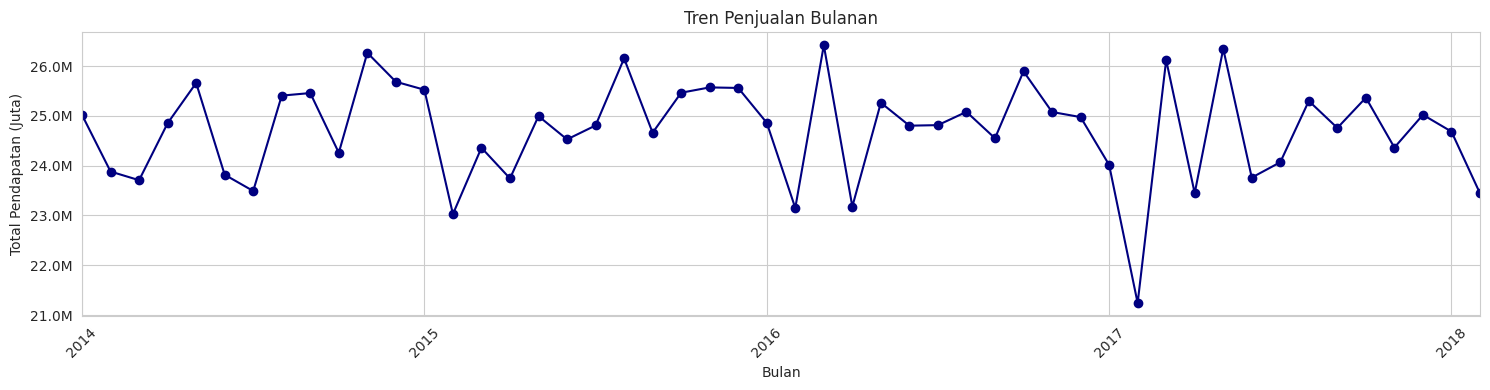

In [ ]:
# Mengubah order_date menjadi periode bulanan (misalnya, 2022-01, 2022-02)
df['order_month'] = df['order_date'].dt.to_period('M')

# Menghitung total pendapatan untuk setiap bulan
monthly_sales = df.groupby('order_month')['revenue'].sum()

# Mengatur ukuran grafik agar lebih jelas
plt.figure(figsize=(15,4))

# Membuat grafik tren penjualan bulanan dengan penanda lingkaran dan garis biru navy
monthly_sales.plot(marker='o', color='navy')

# Mengubah skala sumbu Y menjadi jutaan agar lebih mudah dibaca
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Menambahkan judul dan label pada sumbu grafik
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Pendapatan (Juta)')

# Memutar label sumbu X agar lebih mudah dibaca
plt.xticks(rotation=45)

# Menyesuaikan tata letak agar tidak terpotong
plt.tight_layout()
plt.show()

#INSIGHT
Penjualan secara konsisten berada di kisaran \$24  juta hingga  $26 juta, dengan puncak yang jelas pada akhir musim semi hingga awal musim panas (Mei–Juni) dan titik terendah setiap bulan Januari.


Tren keseluruhan tetap stabil dari tahun ke tahun, yang menunjukkan adanya pola permintaan musiman yang konsisten dan dapat diprediksi.

Namun, penurunan pendapatan yang tajam pada awal tahun 2017 menjadi sebuah outlier, sehingga perlu dilakukan investigasi lebih lanjut untuk mengetahui kemungkinan penyebabnya, seperti gangguan pasar atau promosi yang kurang tepat waktu.

##🔹 2. Tren Penjualan Bulanan (Gabungan Semua Tahun)

Tujuan: Menunjukkan pola musiman secara keseluruhan dengan menggabungkan data penjualan dari semua tahun berdasarkan setiap bulan kalender.

Chart: Line chart (grafik garis)

Jenis EDA: Temporal (analisis deret waktu)

Struktur: Grafik garis dengan penanda (markers), dengan bulan diurutkan dari Januari hingga Desember berdasarkan nomor bulan

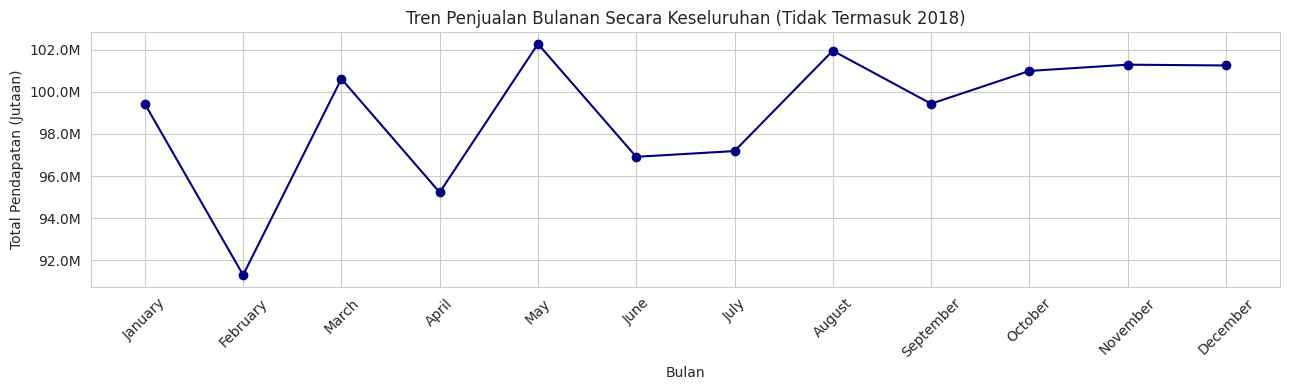

In [ ]:
# 1. Menghapus semua pesanan pada tahun 2018
df_ = df[df['order_date'].dt.year != 2018]   # Mengecualikan data tahun 2018 yang hanya mencakup sebagian tahun
                                            # (yaitu Januari dan Februari 2018) agar total bulanan tidak terdistorsi
                                            # akibat data tahun yang tidak lengkap.
                                            # Saya membuat df_ agar tidak mengubah df asli, sehingga data asli
                                            # tetap utuh untuk analisis lainnya dan hanya melakukan filter
                                            # untuk visualisasi ini.


# 2. Mengelompokkan berdasarkan nomor bulan dan nama bulan, menjumlahkan pendapatan, kemudian mengurutkan berdasarkan nomor bulan
monthly_sales = (
    df_
    .groupby(['order_month_num', 'order_month_name'])['revenue']
    .sum()
    .sort_index()
)

# 3. Menyiapkan visualisasi
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13, 4))
plt.plot(
    monthly_sales.index.get_level_values(1),  # Sumbu X: nama bulan
    monthly_sales.values,                     # Sumbu Y: total pendapatan
    marker='o',                               # Penanda berbentuk lingkaran
    color='navy'                              # Warna garis
)

# 4. Mengubah skala nilai sumbu Y menjadi jutaan agar lebih mudah dibaca
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# 5. Menambahkan judul dan label sumbu
plt.title('Tren Penjualan Bulanan Secara Keseluruhan (Tidak Termasuk 2018)')
plt.xlabel('Bulan')
plt.ylabel('Total Pendapatan (Jutaan)')

# 6. Memutar label sumbu X agar lebih mudah dibaca
plt.xticks(rotation=45)

# 7. Menyesuaikan tata letak agar tidak ada bagian yang terpotong
plt.tight_layout()

# 8. Menampilkan grafik
plt.show()

### NSIGHTS ---

Sepanjang tahun, Januari dimulai dengan performa yang kuat, yaitu sekitar $$99 juta, kemudian diikuti oleh penurunan yang cukup tajam hingga mencapai titik terendah pada bulan April (≈ $95 juta).

Penjualan kembali meningkat pada bulan Mei dan Agustus (≈ $$102 juta) sebelum kemudian berada pada kisaran $99–101 juta dari September hingga Desember.

Pola ini menunjukkan adanya lonjakan kuat setelah Tahun Baru, penurunan pada musim semi, dan peningkatan kembali pada pertengahan musim panas setiap tahunnya.

## 🔹 3. *10 Produk Teratas Berdasarkan Pendapatan (dalam Jutaan)*

Tujuan: Mengidentifikasi produk dengan pendapatan tertinggi untuk menentukan fokus strategi pemasaran dan pengelolaan persediaan.

Chart: Horizontal bar chart (diagram batang horizontal)

Tipe EDA: Univariate (univariat)

Struktur: Batang diurutkan secara descending (menurun) untuk menampilkan 10 produk teratas, dengan nilai pendapatan dikonversi ke dalam satuan jutaan.

/tmp/ipykernel_2531/3586035314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


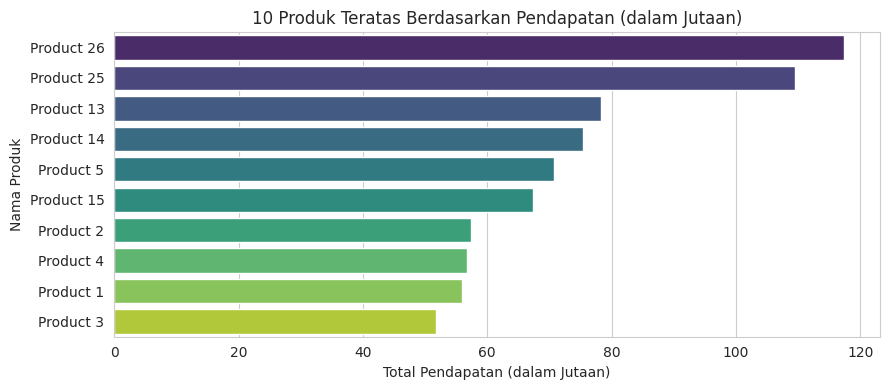

In [ ]:
# Menghitung total pendapatan untuk setiap produk dan mengonversi nilainya ke dalam jutaan
top_prod = df.groupby('product_name')['revenue'].sum() / 1_000_000

# Memilih 10 produk dengan pendapatan tertinggi
top_prod = top_prod.nlargest(10)

# Mengatur ukuran grafik agar lebih jelas
plt.figure(figsize=(9, 4))

# Membuat grafik batang horizontal: sumbu X sebagai pendapatan dalam jutaan, sumbu Y sebagai nama produk
sns.barplot(
    x=top_prod.values,    # Sumbu X: nilai pendapatan dalam jutaan
    y=top_prod.index,     # Sumbu Y: nama produk
    palette='viridis'     # Palet warna untuk batang
)

# Menambahkan judul dan label pada sumbu grafik
plt.title('10 Produk Teratas Berdasarkan Pendapatan (dalam Jutaan)')  # Judul utama
plt.xlabel('Total Pendapatan (dalam Jutaan)')                         # Label sumbu X
plt.ylabel('Nama Produk')                                             # Label sumbu Y

# Menyesuaikan tata letak agar elemen grafik tidak saling bertumpuk
plt.tight_layout()

# Menampilkan grafik
plt.show()

### INSIGHTS ---

Produk 26 dan 25 unggul dengan pendapatan masing-masing sebesar \$118 M dan \$110 M, diikuti penurunan tajam menjadi \$78 M untuk Produk 13, sementara produk di kelompok menengah berada pada kisaran $68–$75 M.

Empat produk dengan pendapatan terendah berada pada kisaran $52–$57 M, yang menunjukkan adanya kendala yang relatif serupa.

Fokuskan pilot project untuk pertumbuhan pada produk dengan performa menengah dan lakukan peningkatan efisiensi pada produk dengan pendapatan terendah untuk mendorong peningkatan yang signifikan.


## 🔹 4. 10 Produk Teratas berdasarkan Rata-rata Margin Keuntungan

Tujuan: Membandingkan tingkat profitabilitas rata-rata antarproduk untuk mengidentifikasi produk dengan margin keuntungan tertinggi.

Chart: Bar chart horizontal

Jenis EDA: Univariate

Struktur: Batang diurutkan secara menurun untuk menampilkan 10 produk teratas berdasarkan nilai rata-rata margin keuntungan.

/tmp/ipykernel_2531/244879924.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


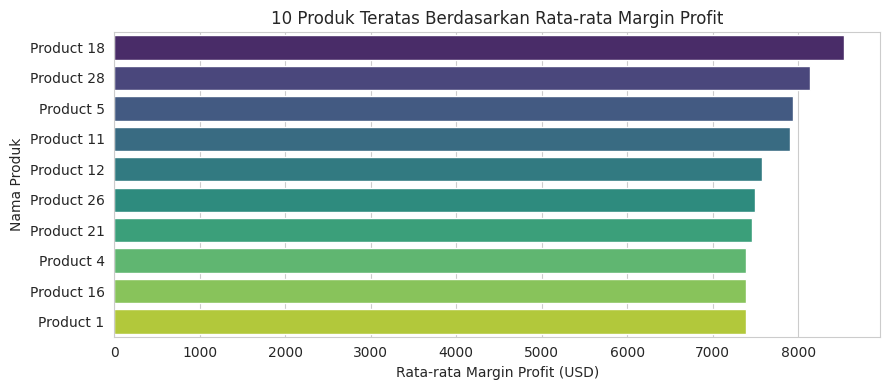

In [ ]:
# 1️⃣ Hitung rata-rata profit per produk dan ambil 10 teratas
top_margin = (
    df.groupby('product_name')['profit']
      .mean()                        # Menghitung rata-rata profit untuk setiap produk
      .sort_values(ascending=False)  # Mengurutkan dari rata-rata profit tertinggi ke terendah
      .head(10)                     # Hanya mengambil 10 produk teratas
)

# 2️⃣ Mengatur ukuran grafik agar lebih jelas
plt.figure(figsize=(9, 4))

# 3️⃣ Membuat grafik batang horizontal
sns.barplot(
    x=top_margin.values,    # Sumbu X: nilai rata-rata profit
    y=top_margin.index,     # Sumbu Y: nama produk
    palette='viridis'       # Palet warna untuk batang
)

# 4️⃣ Menambahkan judul dan label sumbu
plt.title('10 Produk Teratas Berdasarkan Rata-rata Margin Profit')  # Judul grafik
plt.xlabel('Rata-rata Margin Profit (USD)')                       # Label sumbu X
plt.ylabel('Nama Produk')                                         # Label sumbu Y

# 5️⃣ Menyesuaikan tata letak agar tidak terpotong dan menampilkan grafik
plt.tight_layout()
plt.show()

### INSIGHT ---

Produk 18 dan 28 memimpin dengan rata-rata margin keuntungan sekitar \$8,0–8,3 ribu, diikuti oleh Produk 5 dan Produk 11 dengan sekitar \$7,9–8,0 ribu.

Produk dengan performa menengah seperti Produk 12, 26, dan 21 berada pada kisaran \$7,7–7,8 ribu, sedangkan kelompok dengan performa terendah (Produk 4, 16, dan 1) berada pada kisaran $7,4–7,6 ribu.

Memfokuskan strategi optimalisasi margin pada produk-produk dengan performa terbaik dapat membantu meningkatkan profitabilitas produk secara keseluruhan.


##🔹 5. Penjualan berdasarkan Saluran (Pie Chart)

Tujuan: Menampilkan distribusi total penjualan berdasarkan saluran untuk mengidentifikasi jalur penjualan yang paling dominan.

Chart: Pie Chart

Jenis EDA: Univariate

Struktur: Segmen pie dengan label persentase, penggunaan warna untuk memperjelas perbedaan kategori, serta pengaturan sudut awal (start angle) agar visualisasi lebih mudah dibaca.

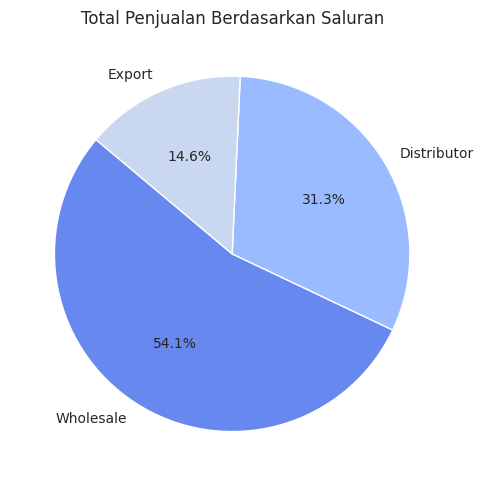

In [ ]:

# Kelompokkan pendapatan berdasarkan saluran penjualan dan urutkan dari yang terbesar
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

# Atur ukuran gambar untuk diagram pie
plt.figure(figsize=(5, 5))

# Buat diagram pie dengan label persentase dan sudut awal yang ditentukan
plt.pie(
    chan_sales.values,                   # Data: nilai pendapatan untuk setiap saluran
    labels=chan_sales.index,             # Label: nama-nama saluran penjualan
    autopct='%1.1f%%',                   # Tampilkan persentase dengan satu angka desimal
    startangle=140,                      # Putar grafik sehingga irisan pertama dimulai pada sudut 140 derajat
    colors=sns.color_palette('coolwarm') # Palet warna untuk setiap irisan
)

# Tambahkan judul untuk memberikan konteks
plt.title('Total Penjualan Berdasarkan Saluran')

# Sesuaikan tata letak agar semua elemen grafik terlihat dengan baik
plt.tight_layout()

# Tampilkan grafik
plt.show()

### INSIGHT ---

Wholesale menyumbang 54% dari total penjualan, diikuti oleh distributor sekitar 31% dan ekspor sekitar 15%, yang menunjukkan adanya ketergantungan pada saluran penjualan grosir domestik.

Untuk mendiversifikasi pendapatan dan mengurangi risiko konsentrasi, perusahaan perlu memprioritaskan pengembangan pasar ekspor melalui pemasaran yang lebih terarah ke pasar luar negeri serta membangun hubungan kemitraan strategis.


## 🔹 6. *Distribusi Average Order Value (AOV)*

**Tujuan:** Memahami distribusi nilai pesanan untuk mengidentifikasi tingkat pengeluaran pelanggan yang umum serta mendeteksi nilai yang menyimpang (*outlier*).

**Chart:** Histogram

**Jenis EDA:** Univariate

**Struktur:** Histogram dengan 50 *bins*, menggunakan batang berwarna dengan garis tepi untuk memperjelas frekuensi nilai pesanan.


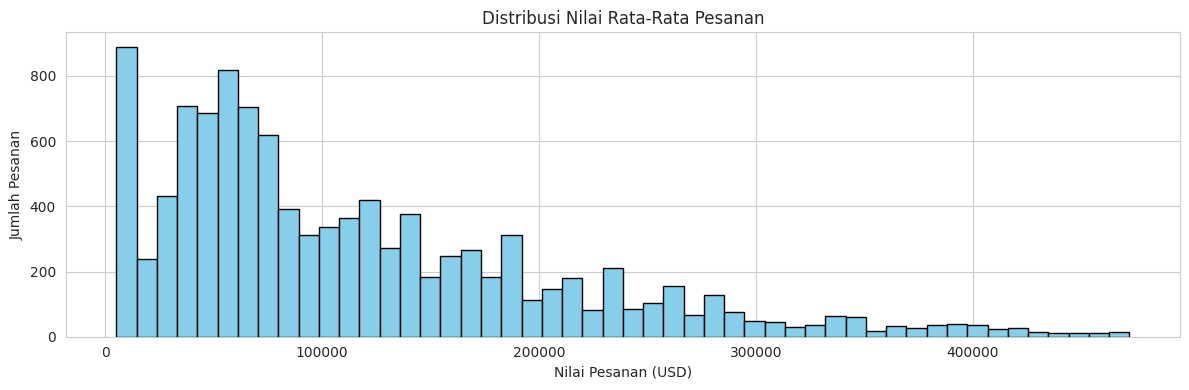

In [ ]:
# Menghitung total revenue untuk setiap pesanan untuk mendapatkan nilai pesanan
aov = df.groupby('order_number')['revenue'].sum()

# Mengatur ukuran grafik agar lebih mudah dilihat
plt.figure(figsize=(12, 4))

# Membuat histogram dari nilai pesanan
plt.hist(
    aov,               # Data: daftar nilai pesanan
    bins=50,           # Jumlah kelompok untuk mengelompokkan nilai pesanan
    color='skyblue',   # Warna isi batang
    edgecolor='black'  # Warna garis tepi batang
)

# Menambahkan judul dan label sumbu untuk memberikan konteks
plt.title('Distribusi Nilai Rata-Rata Pesanan')
plt.xlabel('Nilai Pesanan (USD)')
plt.ylabel('Jumlah Pesanan')

# Menyesuaikan tata letak agar tidak ada bagian yang terpotong
plt.tight_layout()

# Menampilkan grafik
plt.show()

### INSIGHTS —

Distribusi nilai pesanan sangat menceng ke kanan (right-skewed), dengan sebagian besar pesanan terkonsentrasi pada kisaran \$20 ribu hingga \$120 ribu, serta memiliki puncak distribusi yang cukup jelas di sekitar \$50 ribu–$60 ribu.

Terdapat ekor panjang (long tail) dari transaksi bernilai tinggi yang mencapai sekitar \$400 ribu–$500 ribu, tetapi pesanan dengan nilai sebesar tersebut hanya mencakup sebagian kecil dari total volume transaksi.

##🔹 7. Profit Margin % vs. Unit Price

Tujuan: Menganalisis hubungan antara harga per unit dan persentase margin keuntungan pada setiap pesanan.

Chart: Scatter Plot (Diagram Pencar)

Jenis EDA: Bivariat

Struktur: Titik-titik scatter dengan transparansi untuk menunjukkan kepadatan data.

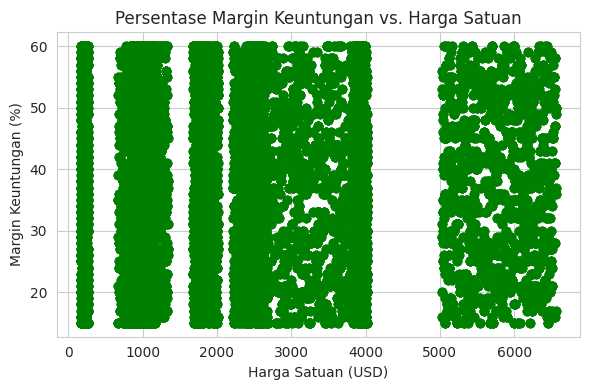

In [ ]:
# Menghitung persentase margin keuntungan untuk setiap data
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

# Mengatur ukuran grafik agar lebih jelas
plt.figure(figsize=(6,4))

# Membuat scatter plot antara harga satuan dan persentase margin keuntungan
plt.scatter(
    df['unit_price'],            # Sumbu X: harga satuan dalam USD
    df['profit_margin_pct'],     # Sumbu Y: persentase margin keuntungan
    alpha=0.6,                   # Tingkat transparansi untuk titik yang saling tumpang tindih
    color='green'                # Warna titik
)

# Menambahkan judul dan label sumbu
plt.title('Persentase Margin Keuntungan vs. Harga Satuan')  # Judul grafik
plt.xlabel('Harga Satuan (USD)')                              # Label sumbu X
plt.ylabel('Margin Keuntungan (%)')                          # Label sumbu Y

# Menyesuaikan tata letak agar tidak terpotong
plt.tight_layout()

# Menampilkan grafik
plt.show()

###INSIGHTS —
Margin keuntungan terkonsentrasi pada kisaran ~18% hingga 60%, tanpa adanya korelasi yang jelas dengan harga per unit, yang berkisar dari hampir \$0 hingga lebih dari $6.500.
Pita horizontal yang padat menunjukkan adanya tingkatan margin yang konsisten di berbagai rentang harga, yang mencerminkan strategi penetapan harga yang seragam.
Outlier di bawah 18%, baik pada titik harga rendah maupun tinggi, dapat mengindikasikan adanya inefisiensi biaya atau masalah dalam penetapan harga yang perlu diteliti lebih lanjut.

## 🔹 8. *Distribusi Harga Satuan per Produk*

**Tujuan:** Membandingkan variasi harga pada berbagai produk untuk mengidentifikasi konsistensi harga dan nilai pencilan (*outliers*).

**Chart:** Boxplot

**Jenis EDA:** Bivariate

**Struktur:** Boxplot dengan label yang diputar agar dapat menampilkan sebaran harga satuan untuk setiap produk.


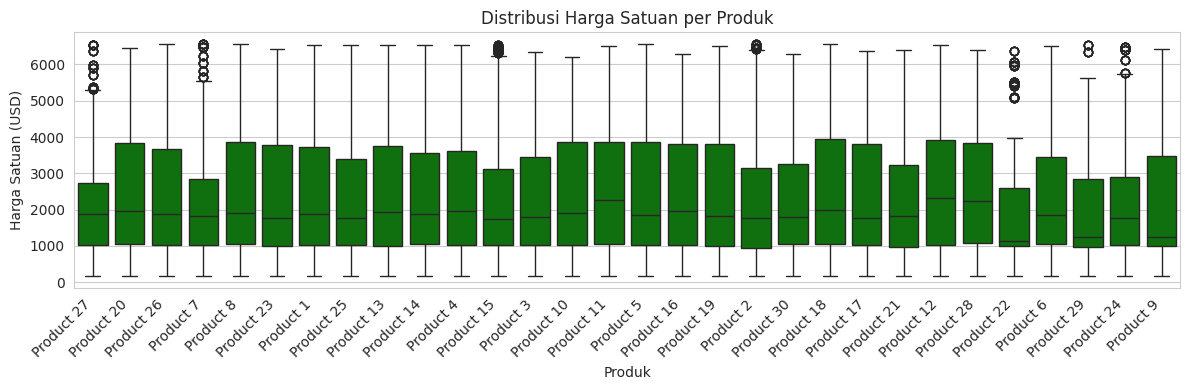

In [ ]:
# Atur ukuran grafik agar lebih jelas
plt.figure(figsize=(12,4))

# Buat boxplot unit_price berdasarkan product_name
sns.boxplot(
    data=df,
    x='product_name',   # Sumbu X: kategori produk
    y='unit_price',      # Sumbu Y: nilai harga satuan
    color='g'            # Warna kotak
)

# Tambahkan judul dan label sumbu
plt.title('Distribusi Harga Satuan per Produk')  # Judul grafik
plt.xlabel('Produk')                             # Label sumbu X
plt.ylabel('Harga Satuan (USD)')                 # Label sumbu Y

# Putar label sumbu X agar lebih mudah dibaca
plt.xticks(rotation=45, ha='right')

# Sesuaikan tata letak agar label tidak terpotong
plt.tight_layout()

# Tampilkan grafik
plt.show()

### INSIGHT ---

Produk 8, 17, 27, 20, dan 28 menunjukkan lonjakan pendapatan pada kategori harga tinggi—jauh di atas batas atas (*upper whisker*)—yang kemungkinan disebabkan oleh pesanan dalam jumlah besar, peluncuran edisi khusus, atau paket premium yang sementara meningkatkan pendapatan.

Sebaliknya, *outlier* pada tingkat harga yang sangat rendah (mendekati \$0–$100) pada Produk 20 dan 27 mengindikasikan adanya pemberian produk secara promosi atau SKU uji coba yang menyebabkan rata-rata harga menjadi lebih rendah.

Untuk memastikan penilaian margin dan harga yang akurat, transaksi yang termasuk *outlier* sebaiknya dikeluarkan dari perhitungan rata-rata.

Selanjutnya, evaluasi apakah anomali tersebut layak dijadikan strategi promosi yang diterapkan secara berkelanjutan atau sebaiknya dihentikan secara bertahap untuk menstabilkan kinerja harga.


##🔹 9. Total Sales by US Region

Tujuan: Membandingkan total penjualan di berbagai wilayah Amerika Serikat untuk mengidentifikasi pasar dengan kinerja terbaik dan wilayah yang memiliki peluang pertumbuhan yang dapat ditargetkan.

Chart: Diagram batang horizontal

Jenis EDA: Perbandingan univariat

Struktur:

Batang diurutkan secara ascending (Northeast → West) untuk menampilkan peringkat dari nilai terendah ke tertinggi dengan jelas.
Sumbu X menampilkan total penjualan dalam jutaan USD.
Sumbu Y menampilkan daftar wilayah.

/tmp/ipykernel_2531/3832908163.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


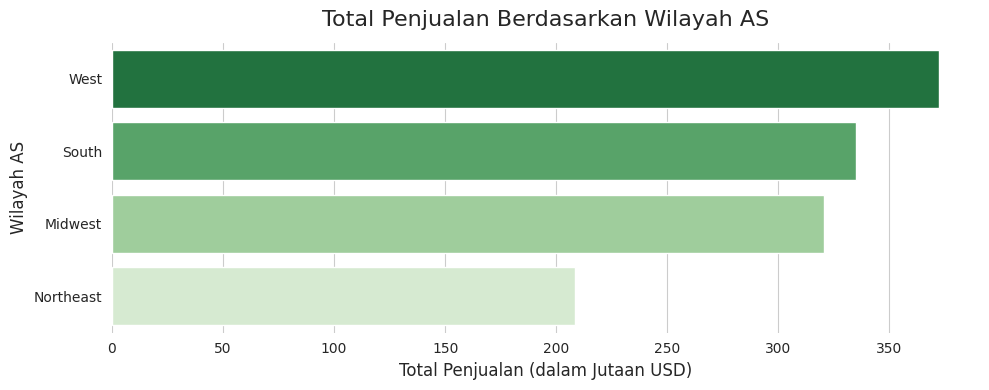

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agregasi total penjualan berdasarkan wilayah (dalam jutaan)
region_sales = (
    df
    .groupby('us_region')['revenue']
    .sum()
    .sort_values(ascending=False)  # sehingga batang diurutkan dari atas → bawah
    / 1e6                         # konversi ke jutaan
)

# 2. Membuat grafik
plt.figure(figsize=(10, 4))
sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    palette='Greens_r'          # hijau gelap → hijau terang
)

# 3. Pemformatan
plt.title('Total Penjualan Berdasarkan Wilayah AS', fontsize=16, pad=12)
plt.xlabel('Total Penjualan (dalam Jutaan USD)', fontsize=12)
plt.ylabel('Wilayah AS', fontsize=12)
plt.xticks(rotation=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

  

## INSIGHT —
**Wilayah** mendominasi dengan penjualan sekitar $360 juta (~35% dari total), yang menunjukkan posisi kepemimpinannya di pasar.

**South & Midwest** masing-masing menyumbang lebih dari $320 juta (~32%), menunjukkan permintaan yang kuat dan konsisten di wilayah tengah.

**Northeast trails** berada di posisi terendah dengan sekitar $210 juta (~20%), yang menunjukkan adanya peluang untuk pertumbuhan dan investasi yang lebih terarah.

**Tindakan**: Fokus untuk mengurangi kesenjangan di wilayah Northeast melalui promosi lokal dan kemitraan strategis, sekaligus mempertahankan strategi nasional yang telah berhasil.


##INSIGHT — Wawasan

California memimpin dengan selisih yang sangat besar, menghasilkan sekitar $230 juta pendapatan dan 7.500 pesanan—lebih dari dua kali lipat dibandingkan negara bagian dengan peringkat tertinggi berikutnya.

Illinois, Florida, dan Texas membentuk kelompok tingkat kedua yang cukup kuat, masing-masing mencatat $85–110 juta pendapatan dengan 3.600–4.600 pesanan.

New York dan Indiana berada di kelompok menengah (mid-pack), dengan sekitar \$54–55 juta pendapatan dan ±2.500 pesanan. Sementara itu, Connecticut, Michigan, dan Massachusetts berada di kelompok terbawah dengan pendapatan $35–44 juta dan 1.600–2.100 pesanan.

Kesesuaian yang cukup erat antara pendapatan dan jumlah pesanan menunjukkan bahwa rata-rata nilai pesanan (Average Order Value/AOV) antarnegara bagian relatif serupa. Untuk mendorong pertumbuhan, fokuskan strategi pada peningkatan volume pesanan di wilayah tingkat menengah serta peningkatan nilai transaksi di wilayah dengan performa lebih rendah.

🔹 10. Total Sales by State (Peta Choropleth)

🎯 Tujuan: Memvisualisasikan distribusi geografis penjualan untuk mengidentifikasi negara bagian dengan performa tinggi dan rendah serta menemukan kesenjangan antarwilayah.

📊 Grafik: Peta Choropleth Amerika Serikat

🔍 Jenis EDA: Geospasial Univariat

📐 Struktur:

Negara bagian diberi warna berdasarkan total penjualan (dalam jutaan USD) menggunakan gradasi warna biru.
Legenda di sebelah kanan menunjukkan skala penjualan (juta USD).
Tooltip saat diarahkan (hover) menampilkan nilai penjualan secara tepat untuk setiap negara bagian.
Peta difokuskan pada Amerika Serikat untuk memberikan konteks regional yang jelas.

In [ ]:
import plotly.express as px

# 1. Agregasi pendapatan berdasarkan negara bagian (dalam jutaan)
state_sales = (
    df
    .groupby('state')['revenue']
    .sum()
    .reset_index()
)
state_sales['revenue_m'] = state_sales['revenue'] / 1e6  # konversi ke jutaan

# 2. Peta choropleth menggunakan Plotly
fig = px.choropleth(
    state_sales,
    locations='state',            # kolom yang berisi kode negara bagian
    locationmode='USA-states',    # memberi tahu Plotly bahwa data merupakan negara bagian AS
    color='revenue_m',
    scope='usa',
    labels={'revenue_m':'Total Sales (M USD)'},
    color_continuous_scale='Blues',
    hover_data={'revenue_m':':.2f'}  # menampilkan 2 angka desimal
)

# 3. Penyesuaian tata letak
fig.update_layout(
    title_text='Total Penjualan berdasarkan Negara Bagian',
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title='Penjualan (Juta USD)',
        ticksuffix='M'
    )
)

fig.show()

##INSIGHTS — WAWASAN

**California** memimpin dengan \$230 juta, diikuti oleh Illinois (\$112 juta) dan Florida (\$90 juta), yang membentuk kelompok teratas yang dominan (> \$90 juta).

Negara bagian tingkat menengah **(mid-tier)**, seperti Texas ($85 juta) dan New York (\$55 juta), menunjukkan performa yang cukup stabil, tetapi masih tertinggal dari tiga negara bagian teratas dengan selisih sekitar \$40–145 juta.

Negara bagian tingkat bawah **(lower-tier)**, seperti New Jersey (\$47 juta) hingga Massachusetts ($35 juta), menunjukkan penurunan secara bertahap yang mengindikasikan penetrasi pasar yang belum merata.

**Tindakan**: Fokuskan strategi pada negara bagian dengan performa terbaik melalui promosi yang disesuaikan, serta luncurkan inisiatif pertumbuhan yang lebih terarah di wilayah dengan penetrasi pasar rendah untuk memperkecil kesenjangan.

##🔹 11. 10 Negara Bagian Teratas berdasarkan Pendapatan dan Jumlah Pesanan

🎯 Tujuan: Mengidentifikasi negara bagian dengan pendapatan tertinggi dan membandingkan volume pesanannya.

📊 Grafik: Dua grafik batang (bar chart)

🔍 Jenis EDA: Multivariat

📐 Struktur: Grafik pertama menampilkan 10 negara bagian teratas berdasarkan pendapatan (dalam jutaan USD), sedangkan grafik kedua menampilkan 10 negara bagian teratas berdasarkan jumlah pesanan.

/tmp/ipykernel_2531/1837458957.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2531/1837458957.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




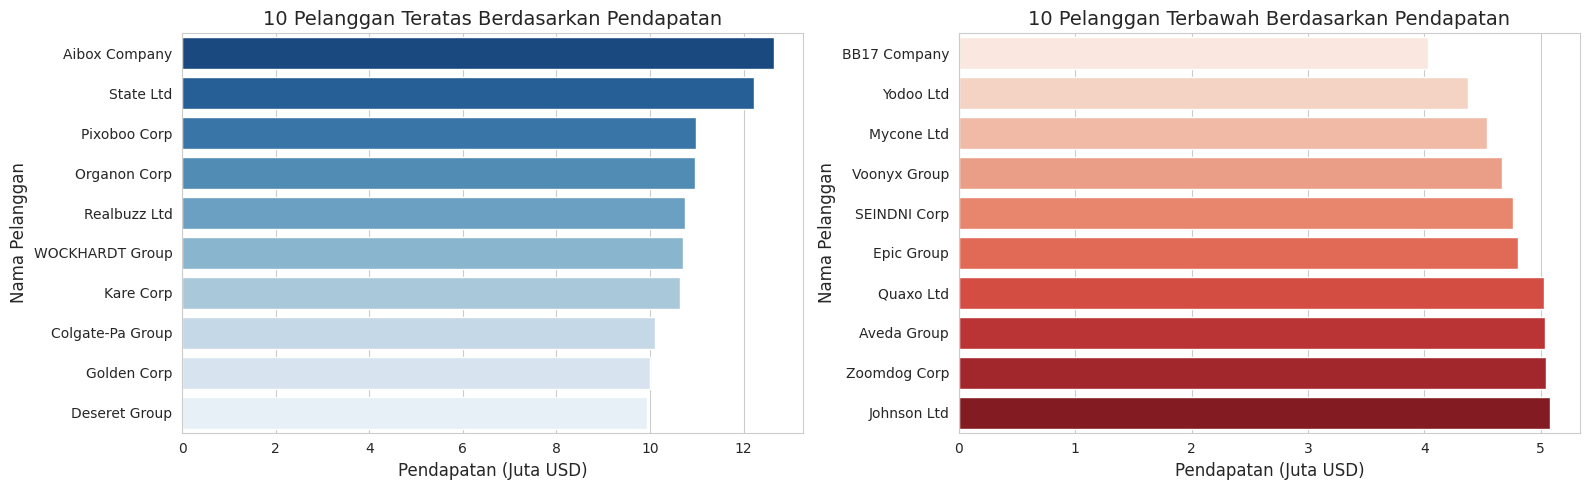

In [ ]:

# 🔝 Menghitung total pendapatan per pelanggan dan memilih 10 teratas
top_rev = (
    df.groupby('customer_name')['revenue']
      .sum()                        # Menjumlahkan pendapatan untuk setiap pelanggan
      .sort_values(ascending=False) # Mengurutkan dari nilai tertinggi ke terendah
      .head(10)                     # Memilih 10 pelanggan teratas
)

# 🔻 Menghitung total pendapatan per pelanggan dan memilih 10 terbawah
bottom_rev = (
    df.groupby('customer_name')['revenue']
      .sum()                        # Menjumlahkan pendapatan untuk setiap pelanggan
      .sort_values(ascending=True)  # Mengurutkan dari nilai terendah ke tertinggi
      .head(10)                     # Memilih 10 pelanggan terbawah
)

# Membuat figure dengan dua subplot yang berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grafik 1: 10 pelanggan teratas berdasarkan pendapatan (dikonversi ke jutaan)
sns.barplot(
    x=top_rev.values / 1e6,    # Sumbu X: pendapatan dalam jutaan
    y=top_rev.index,           # Sumbu Y: nama pelanggan
    palette='Blues_r',         # Palet warna (gradasi biru terbalik)
    ax=axes[0]                 # Ditampilkan pada subplot sebelah kiri
)
axes[0].set_title('10 Pelanggan Teratas Berdasarkan Pendapatan', fontsize=14)  # Judul
axes[0].set_xlabel('Pendapatan (Juta USD)', fontsize=12)                      # Label sumbu X
axes[0].set_ylabel('Nama Pelanggan', fontsize=12)                             # Label sumbu Y

# Grafik 2: 10 pelanggan terbawah berdasarkan pendapatan (dikonversi ke jutaan)
sns.barplot(
    x=bottom_rev.values / 1e6, # Sumbu X: pendapatan dalam jutaan
    y=bottom_rev.index,        # Sumbu Y: nama pelanggan
    palette='Reds',            # Palet warna (merah)
    ax=axes[1]                 # Ditampilkan pada subplot sebelah kanan
)
axes[1].set_title('10 Pelanggan Terbawah Berdasarkan Pendapatan', fontsize=14)  # Judul
axes[1].set_xlabel('Pendapatan (Juta USD)', fontsize=12)                       # Label sumbu X
axes[1].set_ylabel('Nama Pelanggan', fontsize=12)                              # Label sumbu Y

# Menyesuaikan tata letak agar tidak tumpang tindih dan menampilkan kedua grafik
plt.tight_layout()
plt.show()


## INSIGHT — Wawasan
Aibox Company menempati posisi teratas dengan pendapatan \$12,5 juta, diikuti oleh State Ltd (\$12,2 juta). Sementara itu, Deseret Group yang berada di peringkat ke-10 masih menyumbang \$9,9 juta, menunjukkan kelompok teratas yang cukup kompetitif dengan kisaran \$10–12 juta.

Di kelompok terbawah, Johnson Ltd memimpin dengan \$5,1 juta, sedangkan BB17 Company berada di posisi terakhir dengan \$4,1 juta—sekitar setengah dari pendapatan pelanggan teratas.

Penurunan yang cukup tajam dari sekitar \$10 juta+ menjadi \$4–5 juta menunjukkan adanya konsentrasi pendapatan yang tinggi pada pelanggan-pelanggan utama.

**Tindakan**: Prioritaskan retensi dan upselling untuk 10 pelanggan teratas, serta lakukan kampanye pertumbuhan yang lebih tertarget untuk meningkatkan kontribusi kelompok pelanggan dengan pendapatan lebih rendah.

##🔹 12. Rata-rata Margin Keuntungan berdasarkan Saluran Penjualan

Tujuan: Membandingkan rata-rata margin keuntungan di berbagai saluran penjualan untuk mengidentifikasi saluran yang paling dan paling tidak menguntungkan.

Grafik: Bar chart

Jenis EDA: Bivariat

Struktur: Batang vertikal dengan label data yang menampilkan persentase margin, diurutkan secara menurun berdasarkan saluran penjualan.

/tmp/ipykernel_2531/2481077479.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




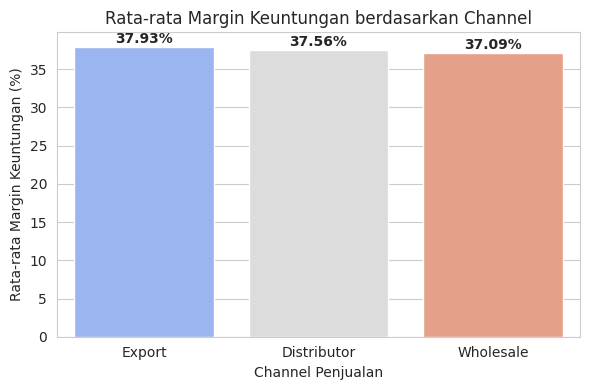

In [ ]:
# 1️⃣ Menghitung rata-rata persentase margin keuntungan untuk setiap channelq
channel_margin = (

    df.groupby('channel')['profit_margin_pct']  # Mengelompokkan berdasarkan channel penjualan
      .mean()                                  # Menghitung rata-rata margin keuntungan %
      .sort_values(ascending=False)            # Mengurutkan channel dari margin tertinggi ke terendah
)

# 2️⃣ Mengatur ukuran grafik agar lebih jelas
plt.figure(figsize=(6, 4))

# 3️⃣ Membuat bar chart rata-rata margin keuntungan berdasarkan channel
ax = sns.barplot(
    x=channel_margin.index,    # Sumbu X: nama channel
    y=channel_margin.values,   # Sumbu Y: nilai rata-rata margin keuntungan
    palette='coolwarm'         # Palet warna untuk batang grafik
)

# 4️⃣ Menambahkan judul grafik dan label sumbu
plt.title('Rata-rata Margin Keuntungan berdasarkan Channel')  # Judul utama
plt.xlabel('Channel Penjualan')                               # Label sumbu X
plt.ylabel('Rata-rata Margin Keuntungan (%)')                 # Label sumbu Y

# 5️⃣ Menambahkan anotasi pada setiap batang dengan persentase margin yang tepat
for i, v in enumerate(channel_margin.values):
    ax.text(
        i,                  # Posisi X (indeks batang)
        v + 0.5,            # Posisi Y (tinggi batang + sedikit jarak)
        f"{v:.2f}%",        # Label teks yang menampilkan persentase dengan dua angka desimal
        ha='center',        # Menempatkan teks di tengah secara horizontal
        fontweight='bold'   # Membuat teks tebal agar lebih mudah dibaca
    )

#6️⃣ Menyesuaikan tata letak agar tidak terpotong dan menampilkan grafik
plt.tight_layout()
plt.show()

## INSIGHT — Wawasan
Export memimpin dengan rata-rata margin sebesar 37,93%, diikuti oleh Distributor (37,56%) dan Wholesale (37,09%).

Selisih margin yang sangat kecil (<0,2%) menunjukkan tingkat profitabilitas yang secara konsisten kuat di seluruh channel.

Keseragaman ini mengindikasikan bahwa perusahaan memiliki pengendalian biaya dan kekuatan penetapan harga yang baik di semua channel.

Untuk memaksimalkan keuntungan, tingkatkan pertumbuhan volume penjualan pada Export sambil tetap mempertahankan efisiensi pada Distributor dan Wholesale.

## 🔹 13. *10 Pelanggan Teratas dan Terbawah Berdasarkan Pendapatan*

**Tujuan:** Mengidentifikasi pelanggan dengan pendapatan tertinggi dan terendah untuk menyesuaikan strategi keterlibatan pelanggan.

**Grafik:** Dua diagram batang horizontal yang ditampilkan berdampingan.

**Jenis EDA:** Multivariat

**Struktur:** Grafik sebelah kiri menampilkan **10 pelanggan teratas berdasarkan pendapatan** (dalam jutaan), sedangkan grafik sebelah kanan menampilkan **10 pelanggan terbawah berdasarkan pendapatan** (dalam jutaan).


/tmp/ipykernel_2531/4070869351.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




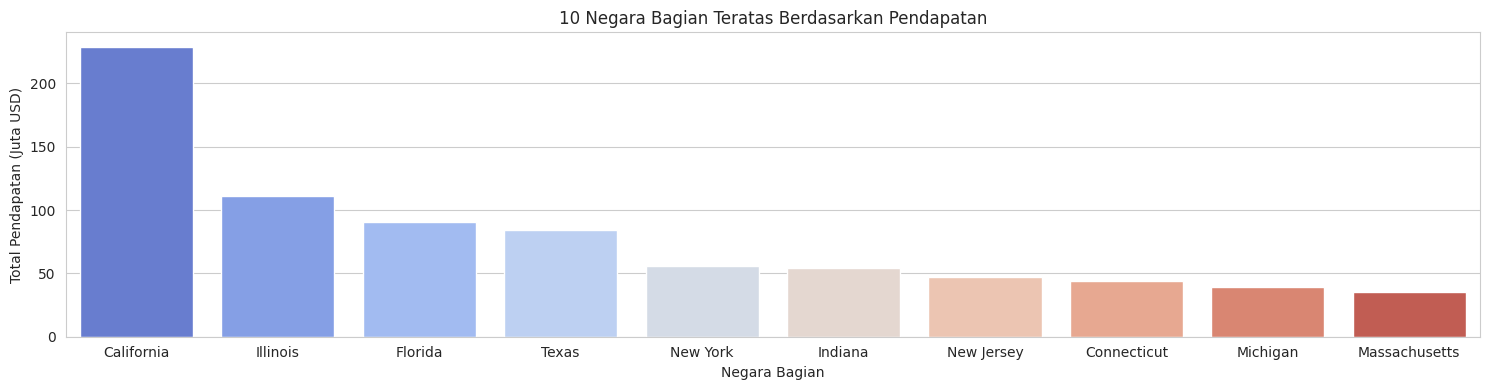

/tmp/ipykernel_2531/4070869351.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




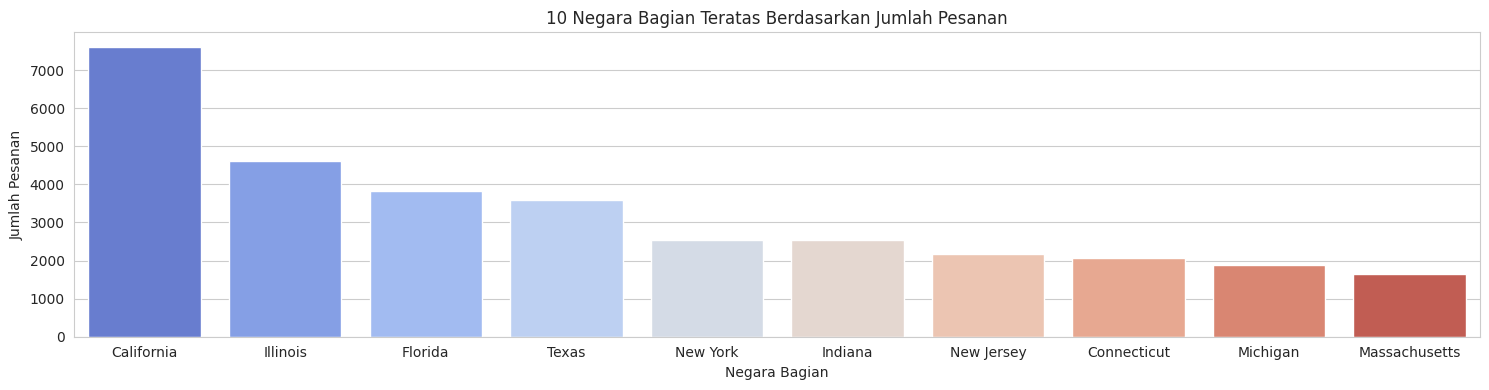

In [ ]:

# Agregasi total pendapatan dan jumlah pesanan unik berdasarkan negara bagian
state_rev = df.groupby('state_name').agg(
    revenue=('revenue', 'sum'),          # Menjumlahkan pendapatan per negara bagian
    orders=('order_number', 'nunique')   # Menghitung jumlah pesanan unik per negara bagian
).sort_values('revenue', ascending=False).head(10)  # Mempertahankan 10 negara bagian teratas berdasarkan pendapatan

# Grafik 1: 10 negara bagian teratas berdasarkan pendapatan (dalam jutaan)
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,                   # Sumbu X: nama negara bagian
    y=state_rev['revenue'] / 1e6,        # Sumbu Y: pendapatan dalam jutaan
    palette='coolwarm'                   # Palet warna
)
plt.title('10 Negara Bagian Teratas Berdasarkan Pendapatan')     # Judul grafik
plt.xlabel('Negara Bagian')                                      # Label sumbu X
plt.ylabel('Total Pendapatan (Juta USD)')                        # Label sumbu Y
plt.tight_layout()                                               # Menyesuaikan tata letak
plt.show()                                                       # Menampilkan grafik

# Grafik 2: 10 negara bagian teratas berdasarkan jumlah pesanan
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,                   # Sumbu X: nama negara bagian
    y=state_rev['orders'],               # Sumbu Y: jumlah pesanan
    palette='coolwarm'                   # Palet warna
)
plt.title('10 Negara Bagian Teratas Berdasarkan Jumlah Pesanan') # Judul grafik
plt.xlabel('Negara Bagian')                                      # Label sumbu X
plt.ylabel('Jumlah Pesanan')                                     # Label sumbu Y
plt.tight_layout()                                               # Menyesuaikan tata letak
plt.show()                                                       # Menampilkan grafik


##🔹 14. Segmentasi Pelanggan: Pendapatan vs. Margin Keuntungan

Tujuan: Mengelompokkan pelanggan berdasarkan total pendapatan dan rata-rata margin keuntungan, dengan menyoroti volume pesanan.

Grafik: Bubble chart (scatter plot dengan ukuran titik yang bervariasi)

Jenis EDA: Multivariat

Struktur:

-Titik pada scatter plot menunjukkan masing-masing pelanggan.

-Sumbu X: Total pendapatan (revenue).

-Sumbu Y: Rata-rata margin keuntungan (profit margin).

-Ukuran titik: Jumlah pesanan (number of orders), sehingga pelanggan dengan

-volume pesanan lebih tinggi ditampilkan dengan ukuran gelembung yang lebih besar.

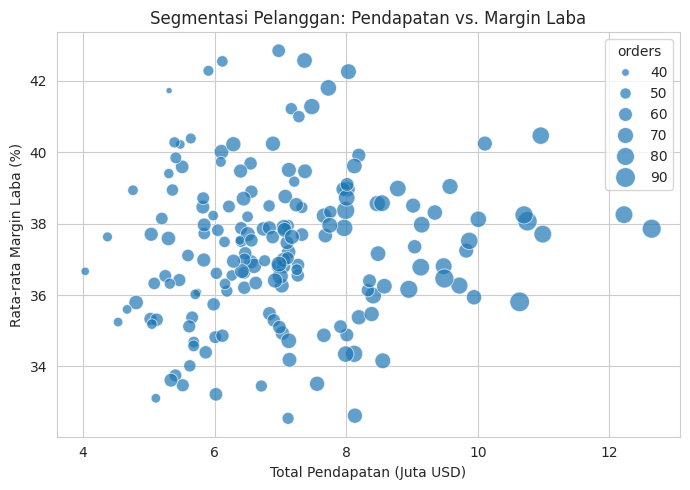

In [ ]:
# Agregasi metrik per pelanggan
cust_summary = df.groupby('customer_name').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin_pct', 'mean'),
    orders=('order_number', 'nunique')
)

# Konversi pendapatan ke dalam jutaan
cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

plt.figure(figsize=(7, 5))

# Bubble chart dengan pendapatan dalam jutaan
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',        # <-- gunakan pendapatan dalam jutaan
    y='avg_margin',
    size='orders',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Segmentasi Pelanggan: Pendapatan vs. Margin Laba')
plt.xlabel('Total Pendapatan (Juta USD)')  # <-- label yang diperbarui
plt.ylabel('Rata-rata Margin Laba (%)')

plt.tight_layout()
plt.show()

### INSIGHT ---

* Pelanggan dengan pendapatan > \$10 juta cenderung mempertahankan margin di kisaran 36–40%, yang menunjukkan bahwa skala bisnis tidak secara signifikan mengurangi profitabilitas.

* Sebagian besar pelanggan berada pada rentang pendapatan \$6–10 juta dan menunjukkan margin yang stabil, yaitu sekitar 34–40%, yang mengindikasikan konsistensi harga pada segmen ini.

* Pelanggan dengan pendapatan < \$6 juta menunjukkan variasi margin yang paling besar, yaitu sekitar 33–43%. Hal ini menunjukkan adanya struktur biaya atau pemberian diskon yang lebih tidak stabil pada pelanggan dengan skala lebih kecil.

* Ukuran bubble (jumlah pesanan) meningkat seiring dengan pendapatan, tetapi tingkat margin tampaknya tidak terpengaruh. Hal ini semakin memperkuat bahwa pendapatan merupakan faktor utama dalam mendorong performa, dibandingkan dengan volume pesanan.


##🔹 15. Heatmap Korelasi Fitur Numerik

Tujuan: Mengidentifikasi hubungan antarvariabel numerik utama untuk menemukan potensi multikolinearitas.

Grafik: Heatmap korelasi

Jenis EDA: Multivariat

Struktur: Heatmap yang dilengkapi dengan koefisien korelasi untuk kolom-kolom numerik yang dipilih.

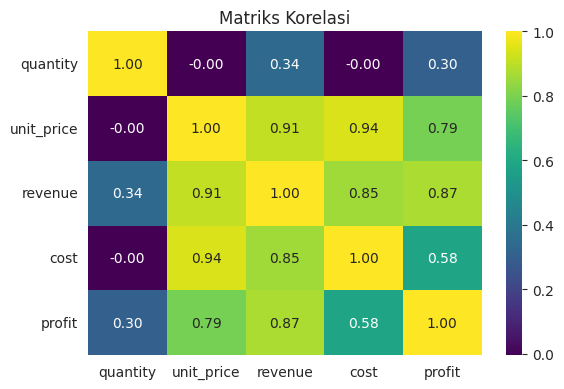

In [ ]:
# Daftar kolom numerik yang akan digunakan dalam perhitungan korelasi
num_cols = ['quantity', 'unit_price', 'revenue', 'cost', 'profit']

# Menghitung matriks korelasi untuk fitur-fitur numerik tersebut
corr = df[num_cols].corr()

# Mengatur ukuran grafik agar lebih jelas
plt.figure(figsize=(6,4))

# Membuat heatmap dengan anotasi dan colormap viridis
sns.heatmap(
    corr,           # Data: matriks korelasi
    annot=True,     # Menampilkan koefisien korelasi pada heatmap
    fmt=".2f",      # Memformat angka hingga dua angka desimal
    cmap='viridis'  # Palet warna untuk heatmap
)

# Menambahkan judul untuk memberikan konteks
plt.title('Matriks Korelasi')

# Menyesuaikan tata letak agar tidak terpotong
plt.tight_layout()

# Menampilkan heatmap
plt.show()

### INSIGHT ---

* **Profit dan revenue** memiliki korelasi yang sangat kuat (0,87), yang menunjukkan bahwa ketika nilai penjualan meningkat, profit cenderung ikut meningkat.

* **Unit price** merupakan faktor utama: memiliki korelasi 0,91 dengan revenue**, 0,79 dengan profit, dan 0,94 dengan cost. Hal ini menunjukkan bahwa keputusan penetapan harga berdampak pada pendapatan sekaligus biaya.

* **Cost** memiliki hubungan yang kuat dengan revenue (0,85), tetapi hubungan yang lebih moderat dengan profit (0,58). Ini menunjukkan bahwa meskipun peningkatan penjualan sering diikuti oleh peningkatan biaya, margin keuntungan tetap dapat bervariasi.

* **Quantity** hampir tidak memiliki korelasi dengan unit price maupun cost (≈0,00) dan hanya memiliki hubungan yang relatif lemah dengan revenue (0,34) dan profit (0,30). Dengan demikian, volume penjualan menjadi faktor sekunder dibandingkan strategi penetapan harga.


# **Menyimpan DataFrame yang Telah Diproses**

In [ ]:
df

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,...,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num,order_month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1,2014-01
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1,2014-01
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1,2014-01
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1,2014-01
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1,2014-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,...,Northeast,40.15511,-74.82877,NaN,11765.736,10022.664,46.0,February,2,2018-02
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,...,Midwest,42.11030,-88.03424,NaN,3474.486,1711.314,33.0,February,2,2018-02
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,...,South,26.24453,-80.20644,NaN,29133.610,14349.390,33.0,February,2,2018-02
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,...,Northeast,42.91002,-78.74182,NaN,20511.246,7206.654,26.0,February,2,2018-02


In [ ]:
# Ekspor DataFrame Akhir ke CSV
df.to_csv('Sales_data(EDA Exported).csv', index=False)

from google.colab import files

files.download('Sales_data(EDA Exported).csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 🔍 **Key Insights**  

* **Siklus Pendapatan Bulanan**
  Pendapatan tetap stabil di kisaran \$23 juta–\$26,5 juta sepanjang 2014–2017, tanpa adanya lonjakan musiman yang konsisten. Penurunan paling tajam (±\$21,2 juta) terjadi pada awal 2017, yang mengindikasikan kemungkinan adanya gangguan satu kali.

* **Komposisi Saluran Penjualan:**
  Wholesale: 54%, Distributor: 31%, dan Ekspor: 15% — terdapat peluang untuk meningkatkan dan memperluas kehadiran di pasar internasional.

* **Produk Teratas (Berdasarkan Pendapatan):**
  Produk 26: \$118 juta, Produk 25: \$110 juta, dan Produk 13: \$78 juta. Produk tingkat menengah menghasilkan \$68–75 juta, sedangkan produk dengan performa terendah menghasilkan \$52–57 juta.

* **Margin Keuntungan**
  Margin keuntungan berada pada rentang yang cukup luas, yaitu sekitar 18% hingga 60%, tanpa adanya korelasi kuat dengan harga per unit. Pola garis horizontal yang padat menunjukkan adanya strategi penetapan harga yang terstandarisasi pada setiap tingkatan produk.

* **Volume Musiman:**
  Tidak terdapat pola bulanan yang kuat, tetapi terlihat sedikit peningkatan volume pada sekitar Mei–Juni. Penurunan pada awal 2017 (±\$21,2 juta) perlu ditelusuri lebih lanjut.

* **Performa Regional:**
  California memimpin dengan sekitar \$230 juta pendapatan dan lebih dari 7.500 pesanan. Illinois, Florida, dan Texas menghasilkan sekitar \$85–110 juta pendapatan dengan ±3.500–4.500 pesanan. New York dan Indiana mencatat sekitar \$54 juta pendapatan dengan lebih dari 2.000 pesanan.


# 💡 **Recommendations**  

1. **Strategi Outlier:** Keluarkan atau kategorikan secara khusus pesanan dalam jumlah besar (*bulk order*) dan SKU promosi saat menghitung nilai rata-rata.

2. **Peningkatan Margin:** Terapkan strategi penetapan harga dari produk-produk teratas pada produk tingkat menengah dan rendah; kurangi biaya pada produk dengan performa rendah.

3. **Pertumbuhan Ekspor:** Investasikan pada pemasaran luar negeri yang lebih terarah serta kerja sama dengan distributor internasional.

4. **Perencanaan Musiman:** Alokasikan anggaran lebih besar pada periode penurunan di bulan Januari dan periode puncak pada Mei–Juni; lakukan investigasi terhadap anomali yang terjadi pada 2017.

5. **Persiapan Dashboard:** Buat tabel agregasi untuk time series, komposisi channel, dan performa produk yang akan digunakan dalam Power BI.
